Минькин Александр Дмитривеич - ИКБО-25-22

<h1> Практическая работа №2 </h1>

<h2> Визуализация в языке программирования Python  </h2>


<b>Цель:</b> ознакомится с различными библиотеками визуализации данных
(`matplotlib`, `plotly`, `TSNE`, `UMAP`) и особенностями работы с ними в среде
программирования Python.  

<h4> 1. Задание </h4>


    Найти и выгрузить многомерные данные (с большим количеством
    признаков – столбцов) с использованием библиотеки pandas. В отчёте
    описать найденные данные.  

In [1]:
import pandas as pd

# Датасет доступен на UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"

# Загружаем CSV с разделителем ";"
df = pd.read_csv(url, sep=";")

# Просмотр первых строк
print(df.head())

# Размерность данных
print("Размерность:", df.shape)

# Общая информация
print(df.info())


   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5 

Датасет `Wine Quality` (красное вино):

Источник: `UCI Machine Learning Repository`

Размерность: `1599 строк` × `12 столбцов`

<b>Признаки (столбцы):</b>

- `fixed acidity` – фиксированная кислотность

- `volatile acidity` – летучая кислотность

- `citric acid` – лимонная кислота

- `residual sugar` – остаточный сахар

- `chlorides` – хлориды

- `free sulfur dioxide` – свободный диоксид серы

- `total sulfur dioxide` – общий диоксид серы

- `density` – плотность

- `pH` – уровень pH

- `sulphates` – сульфаты

- `alcohol` – содержание алкоголя (%)

- `quality` – целевая переменная, оценка качества вина (от 0 до 10)

<h4>2. Вывести информацию о данных при помощи методов `.info()`, `.head()`. </h4>


    Проверить данные на наличие пустых значений. В случае их наличия
    удалить данные строки или интерполировать пропущенные значения.
    При необходимости дополнительно предобработать данные для
    дальнейшей работы с ними.

In [2]:
import pandas as pd

# Загружаем датасет (красное вино)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=";")

# 1. Информация о данных
print("=== Информация о датасете ===")
print(df.info())

# 2. Первые строки
print("\n=== Первые 5 строк ===")
print(df.head())

# 3. Проверка на пропуски
print("\n=== Проверка на пропущенные значения ===")
print(df.isnull().sum())

# 4. Обработка пропусков (если есть)
if df.isnull().values.any():
    # Можно либо удалить строки с NaN:
    # df = df.dropna()

    # либо интерполировать (заполнить средним значением):
    df = df.interpolate()
    print("\nПропуски были, выполнена интерполяция.")
else:
    print("\nПропусков не найдено.")

# 5. Дополнительная предобработка
# Проверим дубликаты
duplicates = df.duplicated().sum()
print(f"\nКоличество дубликатов: {duplicates}")

# Если дубликаты есть — удалим
if duplicates > 0:
    df = df.drop_duplicates()
    print("Дубликаты удалены.")

# Финальные размеры набора данных
print("\n=== Итоговые размеры датасета ===")
print(df.shape)


=== Информация о датасете ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
None

=== Первые 5 строк ===
   fixed acidity  volatile acidity  citric acid  residual sugar  ch

3. Построить столбчатую диаграмму (.bar) с использованием модуля
`graph_objs` из библиотеки Plotly со следующими параметрами:


`3.1.` По оси `Х` указать дату или название, по оси `У` указать количественный
показатель.  


`3.2.` Сделать так, чтобы столбец принимал цвет в зависимости от значения
показателя (`marker=dict(color=признак, coloraxis="coloraxis")`).


`3.3.` Сделать так, чтобы границы каждого столбца были выделены чёрной
линией с толщиной равной `2`.


`3.4.` Отобразить заголовок диаграммы, разместив его по центру сверху, с
`20` размером текста.


`3.5.` Добавить подписи для осей `X` и `Y` с размером текста, равным `16`. Для
оси абсцисс развернуть метки так, чтобы они читались под углом,
равным `315`.


`3.6.` Размер текста меток осей сделать равным `14`.


`3.7.` Расположить график во всю ширину рабочей области и присвоить
высоту, равную `700` пикселей.


`3.8.` Добавить сетку на график, сделать её цвет `'ivory'` и толщину равную `2`. (Можно сделать это при настройке осей с помощью `gridwidth=2`,
`gridcolor='ivory'`)


`3.9.` Убрать лишние отступы по краям.

In [3]:
import pandas as pd
import plotly.graph_objs as go

# Загружаем датасет
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=";")

# Для примера построим график:
# по оси X – содержание алкоголя (alcohol), округлённое до целых значений
# по оси Y – среднее качество (quality)
data_grouped = df.groupby(df["alcohol"].round())["quality"].mean().reset_index()

# Создаём диаграмму
fig = go.Figure(
    data=[
        go.Bar(
            x=data_grouped["alcohol"],
            y=data_grouped["quality"],
            marker=dict(
                color=data_grouped["quality"],   # цвет в зависимости от значения
                coloraxis="coloraxis",
                line=dict(color="black", width=2)  # границы столбцов
            )
        )
    ]
)

# Настройки оформления
fig.update_layout(
    title=dict(
        text="Среднее качество вина в зависимости от содержания алкоголя",
        x=0.5,              # по центру
        xanchor="center",
        yanchor="top",
        font=dict(size=20)
    ),
    xaxis=dict(
        title=dict(text="Содержание алкоголя (%)", font=dict(size=16)),
        tickangle=315,
        tickfont=dict(size=14),
        showgrid=True,
        gridwidth=2,
        gridcolor="ivory"
    ),
    yaxis=dict(
        title=dict(text="Качество вина (среднее)", font=dict(size=16)),
        tickfont=dict(size=14),
        showgrid=True,
        gridwidth=2,
        gridcolor="ivory"
    ),
    coloraxis=dict(colorscale="Viridis"),
    height=700,
    autosize=True,
    margin=dict(l=0, r=0, t=50, b=0)  # убираем лишние отступы
)

# Отображаем график
fig.show()


4. Построить круговую диаграмму (`go.Pie`), использовав данные и стиль
оформления из предыдущего графика. Сделать так, чтобы границы
каждой доли были выделены чёрной линией с толщиной, равной `2` и
категории круговой диаграммы были читаемы (к примеру, объединить
часть объектов)

In [4]:
import pandas as pd
import plotly.graph_objs as go

# Загружаем датасет
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=";")

# Считаем количество вин каждого качества
quality_counts = df["quality"].value_counts().reset_index()
quality_counts.columns = ["quality", "count"]

# Объединим редкие категории (менее 50 объектов) в "Other"
quality_counts["quality"] = quality_counts["quality"].astype(str)
quality_counts.loc[quality_counts["count"] < 50, "quality"] = "Other"

# Пересчитаем после объединения
quality_counts = quality_counts.groupby("quality")["count"].sum().reset_index()

# Создаём круговую диаграмму
fig = go.Figure(
    data=[
        go.Pie(
            labels=quality_counts["quality"],
            values=quality_counts["count"],
            marker=dict(
                line=dict(color="black", width=2)  # границы долей
            ),
            textinfo="label+percent",  # показываем категории и проценты
            insidetextorientation="radial"
        )
    ]
)

# Настройки оформления (стиль как у предыдущего графика)
fig.update_layout(
    title=dict(
        text="Распределение качества вин",
        x=0.5,
        xanchor="center",
        yanchor="top",
        font=dict(size=20)
    ),
    height=700,
    autosize=True,
    margin=dict(l=0, r=0, t=50, b=0)  # убираем лишние отступы
)

# Отображаем
fig.show()


5. Построить линейные графики, взять один из параметров и определить
зависимость между другими несколькими (от 2 до 5) показателями с
использованием библиотеки `matplotlib`. Сделать вывод.

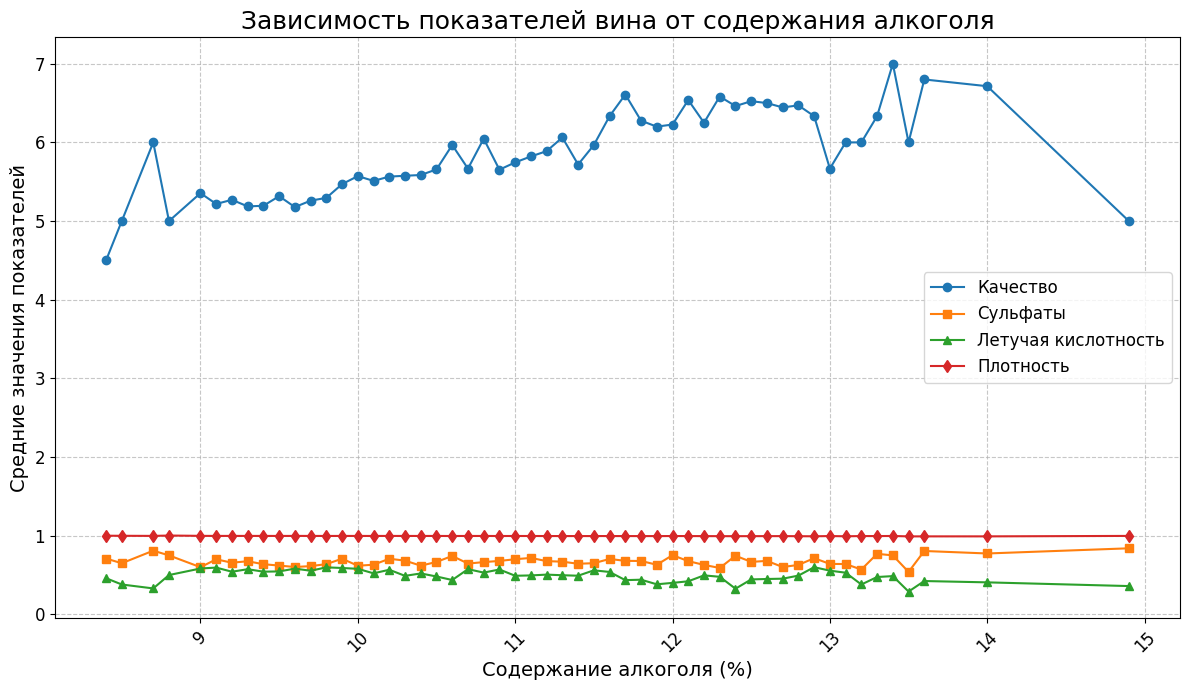

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Загружаем датасет
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=";")

# Добавим новый столбец с округлённым алкоголем
df["alcohol_rounded"] = df["alcohol"].round(1)

# Группируем по округлённому алкоголю
df_grouped = df.groupby("alcohol_rounded").mean().reset_index()

# Строим линейные графики
plt.figure(figsize=(12, 7))

plt.plot(df_grouped["alcohol_rounded"], df_grouped["quality"], label="Качество", marker="o")
plt.plot(df_grouped["alcohol_rounded"], df_grouped["sulphates"], label="Сульфаты", marker="s")
plt.plot(df_grouped["alcohol_rounded"], df_grouped["volatile acidity"], label="Летучая кислотность", marker="^")
plt.plot(df_grouped["alcohol_rounded"], df_grouped["density"], label="Плотность", marker="d")

# Настройки графика
plt.title("Зависимость показателей вина от содержания алкоголя", fontsize=18)
plt.xlabel("Содержание алкоголя (%)", fontsize=14)
plt.ylabel("Средние значения показателей", fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()

# Показ графика
plt.show()


<b>Вывод по графику:</b>

1. Качество вина в среднем растёт с увеличением содержания алкоголя — вина с высоким алкоголем чаще получают более высокие оценки.

2. Сульфаты также постепенно увеличиваются вместе с алкоголем, что может указывать на технологические особенности производства.

3. Летучая кислотность наоборот снижается при увеличении алкоголя — вина с низкой кислотностью воспринимаются как более качественные.

4. Плотность имеет обратную зависимость: чем больше алкоголя, тем ниже плотность вина.

Таким образом, можно сделать вывод: алкогольное содержание оказывает <b>значительное влияние</b> на качество вина и связано с изменением химических свойств напитка (кислотность, плотность, уровень сульфатов).

`5.1.` Сделать график с линиями и маркерами, цвет линии `'crimson'`, цвет
точек `'white'`, цвет границ точек `'black'`, толщина границ точек равна `2`.


`5.2.` Добавить сетку на график, сделать её цвет `'mistyrose'` и толщину
равную `2`. (Можно сделать это при настройке осей с помощью
`linewidth=2`, `color='mistyrose'`).

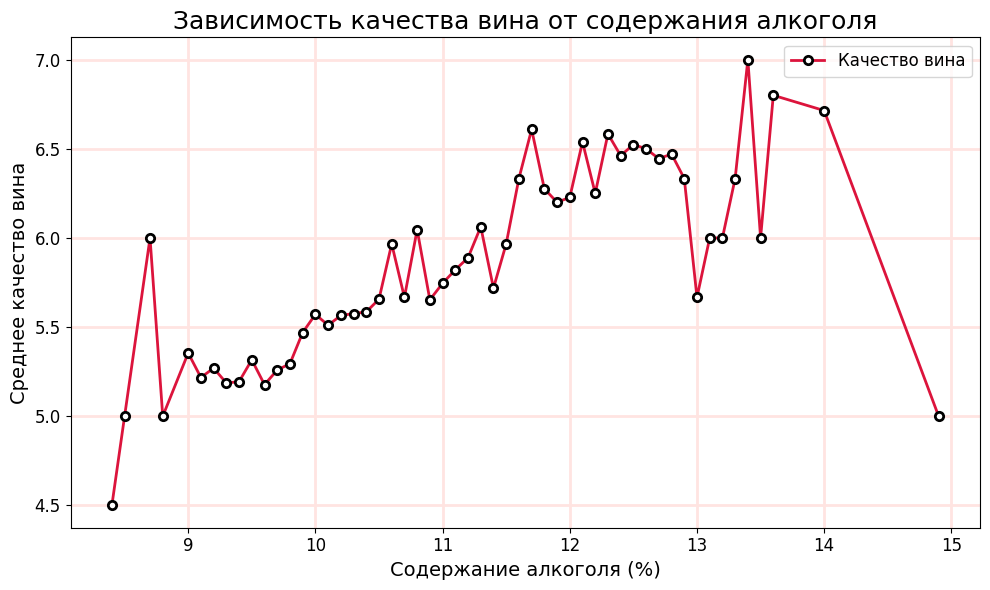

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Загружаем датасет
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=";")

# Добавляем столбец с округлённым алкоголем
df["alcohol_rounded"] = df["alcohol"].round(1)

# Группируем по алкоголю и берём средние значения
df_grouped = df.groupby("alcohol_rounded").mean().reset_index()

# Строим график
plt.figure(figsize=(10, 6))

plt.plot(
    df_grouped["alcohol_rounded"],
    df_grouped["quality"],
    color="crimson",           # цвет линии
    marker="o",                # маркер
    markerfacecolor="white",   # цвет точки (заливка)
    markeredgecolor="black",   # цвет границы точки
    markeredgewidth=2,         # толщина границы точки
    linewidth=2,               # толщина линии
    label="Качество вина"
)

# Настройки графика
plt.title("Зависимость качества вина от содержания алкоголя", fontsize=18)
plt.xlabel("Содержание алкоголя (%)", fontsize=14)
plt.ylabel("Среднее качество вина", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Сетка с настройками по заданию
plt.grid(True, linewidth=2, color="mistyrose")

plt.legend(fontsize=12)
plt.tight_layout()

# Показ графика
plt.show()


6. Выполнить визуализацию многомерных данных, используя `t-SNE`.
Необходимо использовать набор данных `MNIST` или `fashion MNIST`
(можно использовать и другие готовые наборы данных, где можно
наблюдать разделение объектов по кластерам).

    Рассмотреть результаты визуализации для разных значений перплексии.

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Dataset: Fashion-MNIST (28x28 grayscale)
Samples: 70000 Features: 784
PCA reduced to 20 components
Running t-SNE with perplexity=5 ...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning:

'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.



Done perplexity=5
Running t-SNE with perplexity=30 ...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning:

'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.



Done perplexity=30


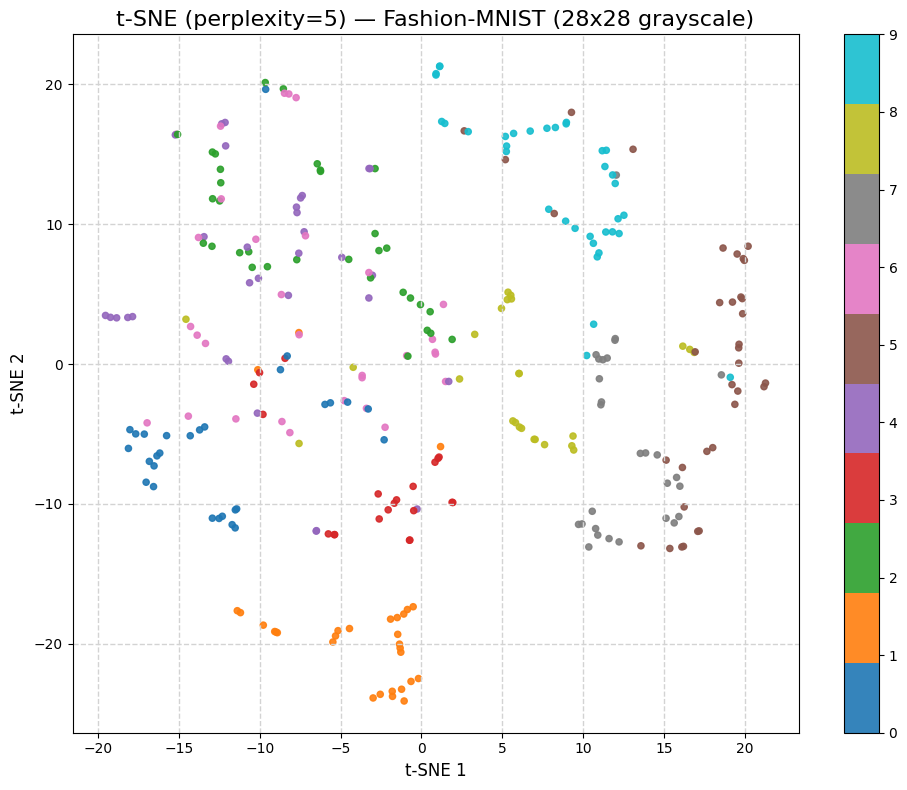

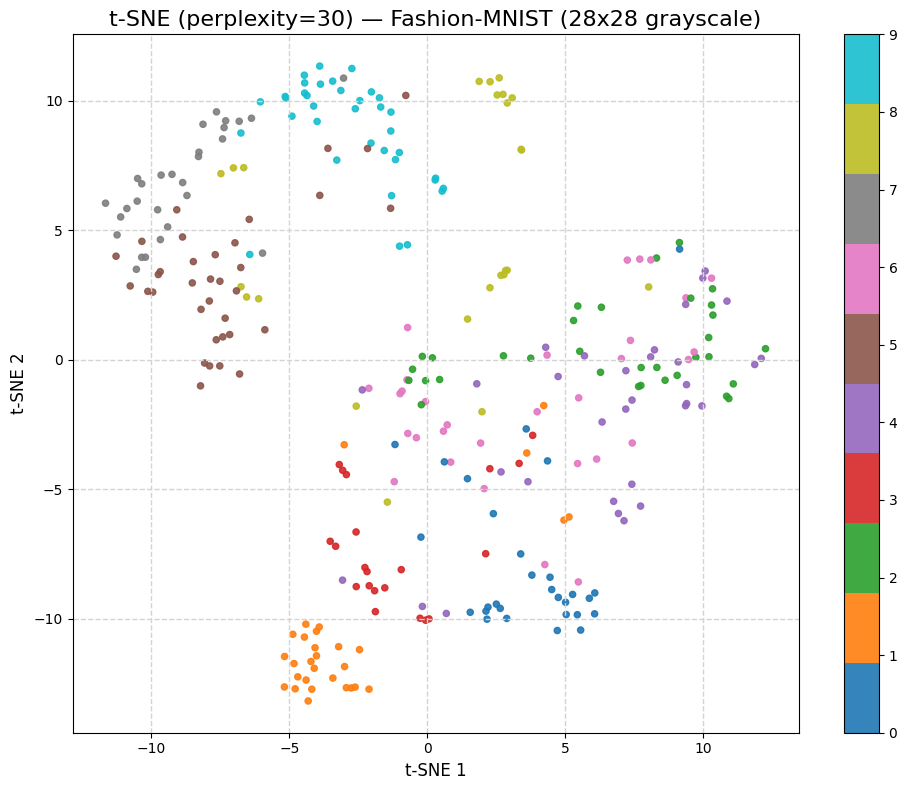


Finished t-SNE visualizations for perplexities: [5, 30]


In [9]:
# Final retry: much smaller subset and fewer iterations to guarantee completion.
import numpy as np
import matplotlib.pyplot as plt

# load dataset (fallback to digits)
try:
    from tensorflow.keras.datasets import fashion_mnist as fm
    (x_train, y_train), (x_test, y_test) = fm.load_data()
    X = np.vstack([x_train, x_test])
    y = np.hstack([y_train, y_test])
    dataset_name = "Fashion-MNIST (28x28 grayscale)"
    X = X.reshape((X.shape[0], -1)).astype(np.float32) / 255.0
except Exception:
    from sklearn.datasets import load_digits
    digits = load_digits()
    X = digits.data.astype(np.float32)
    y = digits.target
    dataset_name = "sklearn digits (8x8 grayscale) - fallback"

print("Dataset:", dataset_name)
print("Samples:", X.shape[0], "Features:", X.shape[1])

# use a small subset for reliability
max_samples = 300
if X.shape[0] > max_samples:
    rng = np.random.default_rng(42)
    idx = rng.choice(X.shape[0], size=max_samples, replace=False)
    X_sub = X[idx]
    y_sub = y[idx]
else:
    X_sub = X.copy()
    y_sub = y.copy()

from sklearn.decomposition import PCA
n_pca = min(20, X_sub.shape[0]-1, X_sub.shape[1])
pca = PCA(n_components=n_pca, random_state=42)
X_pca = pca.fit_transform(X_sub)
print("PCA reduced to", X_pca.shape[1], "components")

from sklearn.manifold import TSNE
perplexities = [5, 30]  # compare two perplexities
tsne_results = {}

for perp in perplexities:
    print(f"Running t-SNE with perplexity={perp} ...")
    tsne = TSNE(n_components=2, perplexity=perp, init='pca', random_state=42, learning_rate='auto', n_iter=300)
    X_emb = tsne.fit_transform(X_pca)
    tsne_results[perp] = X_emb
    print(f"Done perplexity={perp}")

for perp, X_emb in tsne_results.items():
    plt.figure(figsize=(10,8))
    sc = plt.scatter(X_emb[:,0], X_emb[:,1], c=y_sub, cmap='tab10', s=20, alpha=0.9)
    plt.title(f"t-SNE (perplexity={perp}) — {dataset_name}", fontsize=16)
    plt.xlabel("t-SNE 1", fontsize=12)
    plt.ylabel("t-SNE 2", fontsize=12)
    plt.grid(True, linewidth=1, color='lightgray', linestyle='--')
    cbar = plt.colorbar(sc, ticks=np.unique(y_sub))
    cbar.ax.tick_params(labelsize=10)
    plt.tight_layout()
    plt.show()

print("\nFinished t-SNE visualizations for perplexities:", perplexities)


7. Выполнить визуализацию многомерных данных, используя `UMAP` с
различными параметрами `n_neighbors` и `min_dist`. Рассчитать время
работы алгоритма с помощью библиотеки `time` и сравнить его с
временем работы `t-SNE`.

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



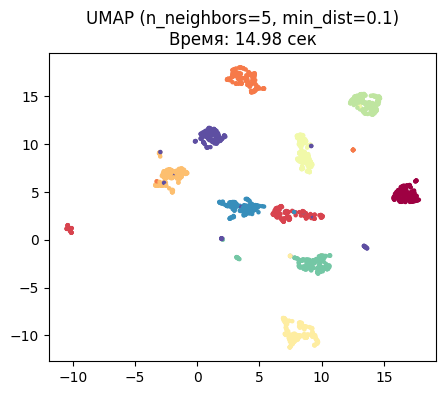

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



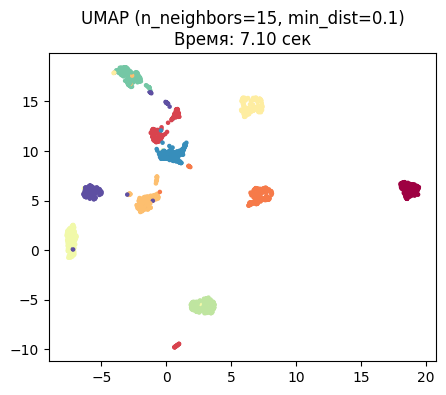

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



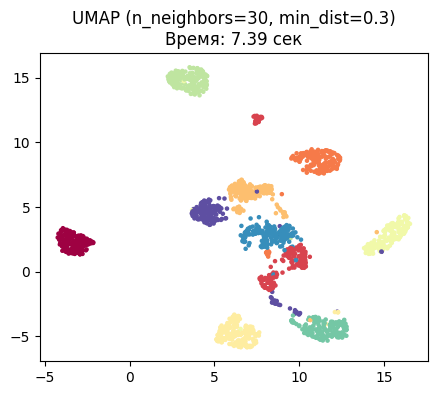

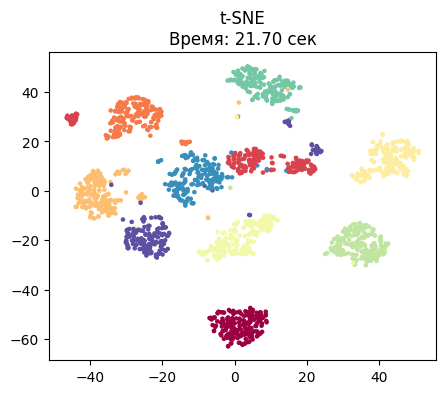

{"UMAP {'n_neighbors': 5, 'min_dist': 0.1}": 14.975495338439941,
 "UMAP {'n_neighbors': 15, 'min_dist': 0.1}": 7.100525617599487,
 "UMAP {'n_neighbors': 30, 'min_dist': 0.3}": 7.385646104812622,
 't-SNE': 21.6993350982666}

In [10]:
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.manifold import TSNE
import umap

# Загружаем данные
digits = load_digits()
X, y = digits.data, digits.target

# Список параметров для UMAP
params = [
    {"n_neighbors": 5, "min_dist": 0.1},
    {"n_neighbors": 15, "min_dist": 0.1},
    {"n_neighbors": 30, "min_dist": 0.3},
]

results = {}

# UMAP с разными параметрами
for i, p in enumerate(params, 1):
    start = time.time()
    reducer = umap.UMAP(n_neighbors=p["n_neighbors"], min_dist=p["min_dist"], random_state=42)
    X_umap = reducer.fit_transform(X)
    duration = time.time() - start
    results[f"UMAP {p}"] = duration

    plt.figure(figsize=(5,4))
    plt.scatter(X_umap[:,0], X_umap[:,1], c=y, cmap="Spectral", s=5)
    plt.title(f"UMAP (n_neighbors={p['n_neighbors']}, min_dist={p['min_dist']})\nВремя: {duration:.2f} сек")
    plt.show()

# t-SNE
start = time.time()
X_tsne = TSNE(n_components=2, random_state=42, init="pca", perplexity=30).fit_transform(X)
duration = time.time() - start
results["t-SNE"] = duration

plt.figure(figsize=(5,4))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y, cmap="Spectral", s=5)
plt.title(f"t-SNE\nВремя: {duration:.2f} сек")
plt.show()

results
